# Week 4: Matrix multiplication and matrix examples

Last week we took a first look at matrices and saw that an $a\times b$ matrix gives instructions (a "function") for turning $bD$ vectors into $aD$ vectors. 

This week we'll take a first look at matrix multiplication. The basic ideas is this: if $G$ is an $b\times c$ matrix that turns a $cD$ vector into a $bD$ vector, and if $F$ is an $a \times b$ matrix that turns a $bD$ vector into an $aD$ vector, then starting wiht a $cD$ vector $v$, you can apply $G$ to get an $bD$ vector called $Gv$. THEN you can apply $F$ to $Gv$ to get an $aD$ vector $F(Gv)$. 

Matrix multiplication tells you how to get this vector in one step: $FG$ is a new $a\times c$ matrix that turns the $cD$ vector $v$ directly into the $aD$ vector $F(Gv)$. Because $F(Gv) = (FG)v$, we drop the parenthesis and just write $FGv$.

Key ideas for this week are:

1. The "row" or "dot product" view of matrix multiplication
2. The "column" or "linear combination" view of matrix multiplication
3. Matrix multiplication and rotation and stretching in 2D
4. Matrix multiplicaiton doesn't commute
5. Membership matrices and a first look at $M^T M$ and $MM^T$.

This week we'll look more at matrix multiplication in more detail, and study some examples of matrices

## Initialization Cells

In [2]:
# This initialization cell imports standard python packages

import numpy as np
import numpy.linalg as la

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.widgets import Slider, Button

import math

# we'll need pandas

import pandas as pd

# We need a random number generator

rng = np.random.default_rng()

In [3]:
# This initialization cell is for material special to Linear Algebra for Data Science

# This function sets up a standard 2D plot for demonstrations involving 2D vectors as arrows.
# Some key features

#  -- You can specify more than one plot. If you call LADS2DSquare(n), you get n plots side-by-side
#     If you call LADS2DSquare(c,r) you get c columns and r rows. Don't do that, instead, use the arguemtns as described below.
#  -- each plot is square and the aspect ratio is set to 1,
#     for true geometry: for example, orthogonal vectors will appear to be perpendicular
#  -- gridlines at integer points
#  -- the origin in the center
#  -- the line x=0 and the line y = 0 are prominent
#
#  -- If you ask for only one plot, you'll get a single instance. In other cases you'll get a 1D array
#     or a 2D array of Axes instances.

# You can set the low and high values of the plot

# Returns two things: the matplotlib figure and axes instances


def LADS2DSquare(ncols=1, nrows=1, xlow=-2., xhigh=2.):
    LADS2Dfig = plt.figure(figsize=[ncols * 6., nrows * 6.])
    nplot = nrows * ncols

    if nplot == 1:
        LADS2Dax = LADS2Dfig.add_axes([0, 0, 1, 1])
        LADS2Dax.set_xlim(xlow, xhigh)
        LADS2Dax.set_ylim(xlow, xhigh)
        LADS2Dax.set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax.axhline(y=0, color='gray')
        LADS2Dax.axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax.set_xticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))
        LADS2Dax.set_yticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))

        LADS2Dax.grid(True)

        return LADS2Dfig, LADS2Dax

# else if nplot>1...
    LADS2Dax = LADS2Dfig.subplots(nrows, ncols)
    if min(nrows, ncols) == 1:
        for i in range(nplot):
            LADS2Dax[i].set_xlim(xlow, xhigh)
            LADS2Dax[i].set_ylim(xlow, xhigh)
            LADS2Dax[i].set_aspect('equal')

            # Add x and y axes crossing at origin (0.0)
            LADS2Dax[i].axhline(y=0, color='gray')
            LADS2Dax[i].axvline(x=0, color='gray')

            # Set ticks to a reasonable number
            LADS2Dax[i].set_xticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].set_yticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].grid(True)
# end for

        return LADS2Dfig, LADS2Dax
# end "if nplot>1"

#else if nrows>1 and ncols > 1...

    for i, j in np.ndindex(nrows, ncols):
        LADS2Dax[i, j].set_xlim(xlow, xhigh)
        LADS2Dax[i, j].set_ylim(xlow, xhigh)
        LADS2Dax[i, j].set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax[i, j].axhline(y=0, color='gray')
        LADS2Dax[i, j].axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax[i, j].set_xticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].set_yticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].grid(True)

    return LADS2Dfig, LADS2Dax


# This method draws arrows on an matplotlib axes class.

# this is a generic method, designed to be added to the matplotlib Axes class
# The hsv color map is good for drawing circles of vectors (where the end of the list will be near the beginning). Other colormaps may be better
# for arbitrary lists. See https://matplotlib.org/stable/tutorials/colors/colormaps.html


def LADS2DDrawVectorList(self, VectorList, cmap=cm.hsv,columns=False):
    #norm.autoscale(0,len(VectorList))
    VList = VectorList
    if columns: 
        VList = VectorList.T
        
    zeroes = np.zeros(len(VList))
    self.quiver(zeroes,
                zeroes,
                VList[:, 0],
                VList[:, 1],
                color=cmap(np.linspace(0, 1, len(VList),endpoint=False)),
                angles='xy',
                scale_units='xy',
                scale=1)


# This command adds the method above to Axes
plt.Axes.LADS2DDrawVectorList = LADS2DDrawVectorList

# these methods draws a single arrow in 2D and 3D


def LADS2DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [Vector[0]], [Vector[1]],
                color=col,
                angles='xy',
                scale_units='xy',
                scale=1)


plt.Axes.LADS2DDrawVector = LADS2DDrawVector

# Creates a 2D rotation matrix: rotates by the angle theta, specified in radians, counterclockwise


def RotationMatrix2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


### End of initialization cells

## Matrix multiplication in words

Remember that if $F$ is an $n\times k$ matrix, so it has $k$ columns, then you apply $F$ to a $kD$ vector $v$ to get an $nD$ vector $Fv$ (or in Python, $F@v$). If the number of columns of $F$ doesn't match the number of entries of $v$, then $F@v$ doesn't make any sense. Something similar happens with matrices. Here are some important facts about matrix multiplication.

1. If $F$ and $G$ are matrices, then you can multiply $F$ and $G$ to get $FG$ only when the number of **columns** of $F$ matches the number of **rows** of $G$. 

2. If $F$ is an $a \times b$ matrix, and if $G$ is a $b\times c$ matrix, then we can form their product $FG$, or, in Python, $F@G$. The new matrix $F@G$ is an $a\times c$ matrix: it has the same number of rows as $F$, and the same number of columns as $G$.

3. When multiplying $F$ and $G$, you appy $F$ to the **columns** of $G$,considered as vectors, to get the **columns** of $FG.$ As with applying a matrix to a vector, you then have two descriptions of the columns of $FG$. One description involves the **rows of $F$,** and the other involves the **columns of $F$**. 

3. Matrix multiplication corresponds to composition of vector-valued functions. (We'll explain this more carefully below)


### When you multiply $F$ and $G$ to get $FG$, you apply $F$ to the columns of $G$.

Let $F$ be an $a \times b$ matrix, and let $G$ be a $b\times c$ matrix. Using Python notation, let $G[:,0],...,G[:,c-1]$ be the columns of $G$, so
$$
G = \begin{bmatrix} | & & | \\
                    G[:,0] & \ldots & G[:,c-1]  \\
                    | & & | 
                    \end{bmatrix}.
$$
Notice that each column is a $b$-dimensional vector, and so we can apply $F$ to it.
$FG$ is the matrix with columns $F@G[:,0],\ldots,F@G[:,c-1]$, that is,
>**Fact:**
$$
FG = \begin{bmatrix} | & & | \\
                    F@G[:,0] & \ldots & F@G[:c-1]  \\
                    | & & | 
                    \end{bmatrix}.
$$          

Put another way, 
>**Fact:** The $j$ column of $FG$ is the matrix $F$ applied to the $j$ column of $G$:
$$
(F@G)[:,j] = F @ (G[:,j])
$$

### $FG$ in terms of the rows of $F$: the row or dot product view

Let $F$ be an $a\times b$ matrix, and let $G$ be a $b \times c$ matrix, with columns $G[:,0],\ldots, G[:,c-1]$, so
$$
G = \begin{bmatrix} | & & | \\
                    G[:,0] & \ldots & G[:,c-1]  \\
                    | & & | 
                    \end{bmatrix}.
$$
We learned above that the $j$ column of $FG$ is $F@ G[:,j]$, the vector obtained by applying the matrix $F$ to the vector $G[:,j]$. 

We can find the entries of $F@G[:,j]$ by taking the dot product of the **rows** of $F$ with $G[:,j]$. Explicitly, let $F[0],...,F[a-1]$ be the rows of $F$, so
$$
F = \begin{bmatrix} \text{---} & F[0] & \text{---} \\
                   \text{---} & F[1] & \text{---} \\
                   & \vdots & \\
                   \text{---} & F[a-1] & \text{---}
                   \end{bmatrix}.
$$
Then the $j$ column of $FG$ is
$$
F@G[:,j] = \begin{bmatrix} 
 F[0] \cdot G[:,j] \\
 F[1] \cdot G[:,j] \\
     \vdots \\
 F[a-1] \cdot G[:,j]
\end{bmatrix}.
$$
Putting all the columns together, we have 
$$
FG = \begin{bmatrix} F[0] \cdot G[:,0] &  \ldots & F[0]\cdot G[:,j] & \ldots & F[0] \cdot G[:,c-1] \\
                          \vdots   &         & \vdots        &  & \vdots       \\
                     F[i] \cdot G[:,0] & \ldots & F[i] \cdot G[:,j] &  \ldots & F[i] \cdot G[:,c-1] \\
                        \vdots  &         & \vdots        &  & \vdots       \\
                      F[a-1] \cdot G[:,0] & \ldots & F[a-1] \cdot G[:,j] &  \ldots & F[a-1] \cdot G[:,c-1] 
                   \end{bmatrix}
$$
Put another way:
>**Fact:** The entry in row $i$ and column $j$ of $FG$ is the dot product $F[i] @ G[:,j]$ of the $i$ row of $F$ with the $j$ column of $G$: in Python, $FG[i,j] = F[i] @ G[:,j].$



### The columns of $FG$ in terms of the columns of $F$: the column or linear combination view

Let $F$ be an $a\times b$ matrix. Recall that if $v$ is a $bD$-vector, then $Fv$ is the linear combination of the columns of $F$ with coefficients given by the entries of $v$. Explicitly, if $F[:,0],\ldots,F[:,b-1]$ are the columns of $F$ so

$$
F =           \begin{bmatrix} | & & | \\
                    F[:,0] & \ldots & F[:,b-1]  \\
                    | & & | 
                    \end{bmatrix},
$$

and if $v = [v[0],\ldots,v[b-1]]$, then 

$$
F@v = v[0] * F[:,0] +\ldots + v[b-1] * F[:,b-1].
$$
Notice that each $v[i]$ is a scalar, so we've written $F@v$ as a linear combination of the columns of $F$.

Turning to the matrix $G$, if the $j$ column of $G$ has entries $G[i,j]$, then the $j$ column of $FG$ is

$$
FG[:,j] = G[0,j] * F[:,0] + \ldots + G[b-1,j] * F[:,b-1].
$$

Notice that $G[i,j]$ is a scalar, while $F[:,i]$ is a vector.

Summarizing: 
>**Fact:** The $j$ column of $FG$ is the linear combination of the columns of $F$ using as coefficients the $j$ column of $G$.


## Numerical examples of matrix multiplication

In [4]:
# Here is a random 2 by 3 matrix F
F = rng.integers(low=-5.,high=5.,size=(2,3))
print(F)

[[ 3  0 -3]
 [-1  4  4]]


In [5]:
# Here is a 3 by 3 matrix G

G = rng.integers(low=-5.,high=5.,size=(3,3))
print(G)

[[ 3 -1  2]
 [ 0  1 -4]
 [-5 -3 -2]]


In [6]:
# Let's check that the [i,j] entry of F@G is given by 
# the dot product of the i row of F with the j row of G
FG = F@G

a,c = FG.shape
print(a,c)
for i in range(a):
    for j in range(c):
        print(f"FG[{i},{j}] = {FG[i,j]}; F[{i}] @ G[:,{j}] = {F[i] @ G[:,j]}")

2 3
FG[0,0] = 24; F[0] @ G[:,0] = 24
FG[0,1] = 6; F[0] @ G[:,1] = 6
FG[0,2] = 12; F[0] @ G[:,2] = 12
FG[1,0] = -23; F[1] @ G[:,0] = -23
FG[1,1] = -7; F[1] @ G[:,1] = -7
FG[1,2] = -26; F[1] @ G[:,2] = -26


#### **Do it:** Repeat the experiment above with other chocies of $F$ and $G$. 
Your $F$ and $G$ should have different shapes from above. They can be any shape so long as $F@G$ is defined. (Choosing shapes for $F$ and $G$ so that $FG$ is defined is part of the exercise)

In [8]:
# You can start your work in this cell
F = np.array([[1,2],[3,4],[5,6]])
G = np.array([[1,2],[3,4]])

FG = F@G
a, b = FG.shape
print(a,b)
for i in range(a):
    for j in range(b):
        print(f"FG[{i},{j}] = {FG[i,j]}; F[{i}] @ G[:,{j}] = {F[i] @ G[:,j]}")

3 2
FG[0,0] = 7; F[0] @ G[:,0] = 7
FG[0,1] = 10; F[0] @ G[:,1] = 10
FG[1,0] = 15; F[1] @ G[:,0] = 15
FG[1,1] = 22; F[1] @ G[:,1] = 22
FG[2,0] = 23; F[2] @ G[:,0] = 23
FG[2,1] = 34; F[2] @ G[:,1] = 34


Now let's check that the $i$ column of $F@G$ is a linear combination of the columns of $F$, 
with coefficients given by the $j$ column of $G$.


In [11]:
# Now let's check that the i column of F@G is a linear combination of the columns of F, 
# with coefficients given by the i column of G.

# Here is a random 3 by 5 matrix F
F = rng.integers(low=-5.,high=5.,size=(3,5))
print("F:")
print(F)

# Here is a random 5 by 2 matrix G
G =  rng.integers(low=-5.,high=5.,size=(5,2))
print("G:")
print(G)

FG = F@G
print("F@G:")
print(FG)

a,c=FG.shape
a,b=F.shape

for i in range(c):
    col = np.zeros_like(FG[:,i]) # makes a vector of zeros of the same dimension as the i column of FG.
    # this for loop accumulates col = G[0,i]* F[:,0] + ... + G[b-1,i]@ F[:,b-1]
    for j in range(b):
        col = col + G[j,i] * F[:,j]
    print(f"The {i} column of FG is ",FG[:,i])
    print(f"The corresponding linear combination of columns of F is ",col)


F:
[[ 1 -2  0 -4 -1]
 [-1  1 -2  0  4]
 [ 4  2  2 -2  1]]
G:
[[-1  1]
 [-4  3]
 [ 1 -3]
 [-2 -3]
 [-3  1]]
F@G:
[[ 18   6]
 [-17  12]
 [ -9  11]]
The 0 column of FG is  [ 18 -17  -9]
The corresponding linear combination of columns of F is  [ 18 -17  -9]
The 1 column of FG is  [ 6 12 11]
The corresponding linear combination of columns of F is  [ 6 12 11]


#### **Do it:** Repeat the experiment above with other chocies of $F$ and $G$. 
Your $F$ and $G$ should have different shapes from above. They can be any shape so that $F@G$ is defined.

In [14]:
# you can start your work in this cell

F = rng.integers(low=-10.,high=10.,size=(3,5))
print("F:")
print(F)

G = rng.integers(low=-10.,high=10.,size=(5,3))
print("G:")
print(G)

FG = F@G
print("F@G:")
print(FG)

a,c = FG.shape
a,b = F.shape

for i in range(c):
    col = np.zeros_like(FG[:,i])
    for j in range(b):
        col = col + G[j,i] * F[:,j]
    print(f"The [i] column of FG is ",FG[:,i])
    print(f"The corresponding linear combination of columns of F is ", col)

F:
[[-10   4  -6  -8   0]
 [ -6   4   8   7  -1]
 [ -3  -8   2  -6   9]]
G:
[[ 6 -8 -2]
 [ 5  5  6]
 [ 9 -5  3]
 [-5  8  9]
 [ 3  1  2]]
F@G:
[[-54  66 -46]
 [ 18  83 121]
 [ 17 -65 -72]]
The [i] column of FG is  [-54  18  17]
The corresponding linear combination of columns of F is  [-54  18  17]
The [i] column of FG is  [ 66  83 -65]
The corresponding linear combination of columns of F is  [ 66  83 -65]
The [i] column of FG is  [-46 121 -72]
The corresponding linear combination of columns of F is  [-46 121 -72]



## Rotation and stretching

### Composition of operations corresponds to matrix multiplication

Let's reproduce the unit circle and some colored 2D vectors from last week.

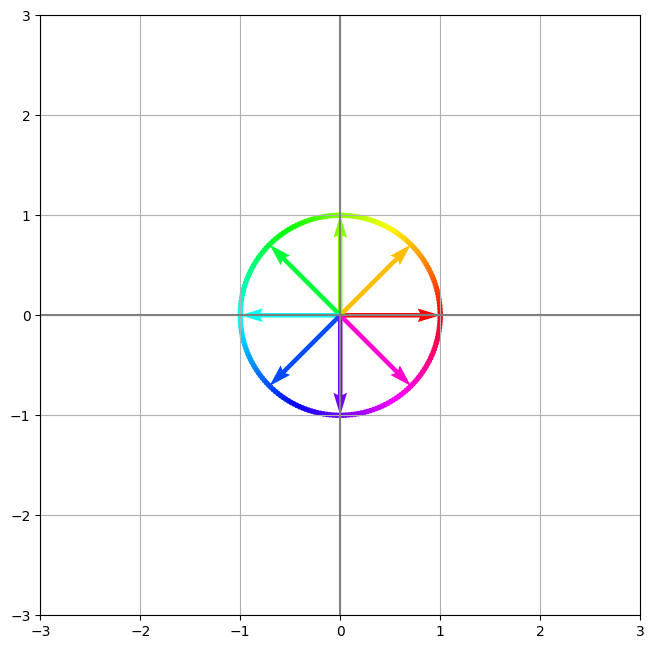

In [17]:
# Create an array from 0 to 2pi with 200 points
theta = np.linspace(0, 2*np.pi, 200)

# UnitCirclePoints a matrix with 2 rows and 200 columns 
# Each column is a point on the unit circle.

UnitCirclePoints = np.array([np.cos(theta), np.sin(theta)])

# I want to color the cirlce when we draw it. colors is a list of values between 0 and 1, so it works as input
# to a matplotlib color map

colors  = theta/(2*np.pi)

nwedges = 8
theta = np.linspace(0.,1.,nwedges,endpoint=False) * 2.0 * np.pi  
List_of_Arrows_on_Circle = np.array([np.cos(theta),np.sin(theta)])

# Now let's draw those nwedges vectors as arrows so you can see what I mean.

fig,ax = LADS2DSquare(xlow=-3.0,xhigh=3.0)
ax.LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax.scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

Recall from last week that a diagonal matrix $D$ stretches along the x and y axes.

Remember that if $t$ is an angle in radians, then the rotation matrix
$$
R = \begin{bmatrix} \cos(t) & -\sin(t) \\ \sin(t) & \cos(t) \end{bmatrix}
$$
rotates the plane counterclockwise by the angle $t$.

In the following code cell we compare applying $D$ and then $R$ to applying $R@D$. We should get the same answer:
> If $F$ and $G$ are matrices so that $FG$ is defined, then applying $FG$ is the same as applying $G$ and then $F$.

First let's review the visual effect of applying a diagonal matrix $D$.

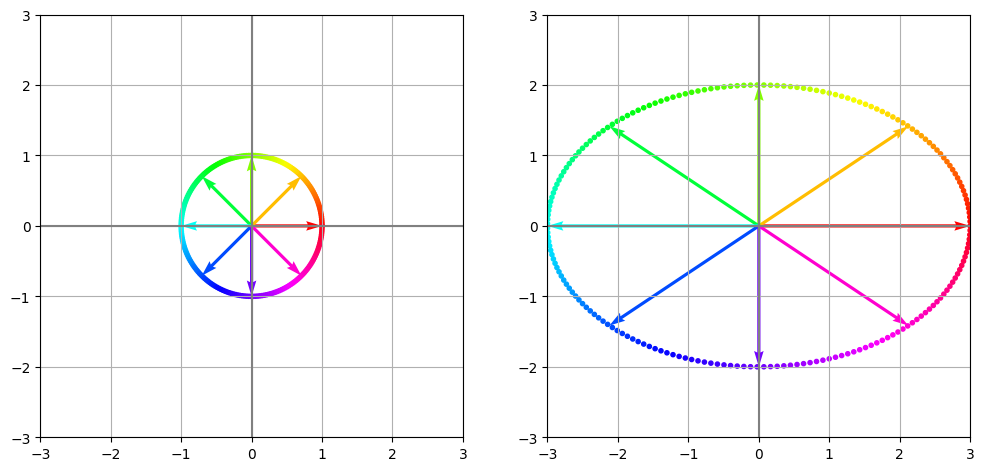

In [18]:
# Recall from last week that a diagonal matrix stretches along the x and y axes.
D = np.diag([3,2])

fig,ax = LADS2DSquare(ncols=2,xlow=-3.,xhigh=3.)

DonArrows = D @ List_of_Arrows_on_Circle
DonCircle = D @ UnitCirclePoints

ax[0].LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)
ax[1].LADS2DDrawVectorList(DonArrows,columns=True)
ax[1].scatter(*DonCircle,marker=".",c=colors,cmap=cm.hsv)



Now let's follow by applying $R$ to the ellipse we got from $D$. And, at the same time, we'll draw $R@D$ applied to the unit circle. We should get the same thing. 

Text(0.5, 1.0, 'R@D applied to the unit circle')

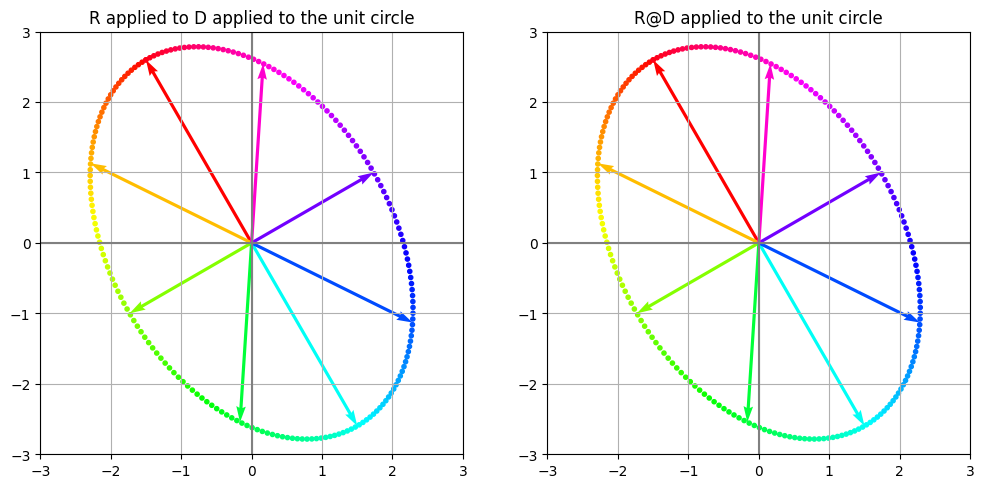

In [19]:
# R rotates counterclockwise 120 degrees or 2 pi/3 radians 
R = RotationMatrix2D(2* np.pi/3)

#Let's apply R to D applied to the unit circle

RonDonArrows = R @ DonArrows
RonDonCircle = R @ DonCircle

fig,ax = LADS2DSquare(ncols=2,xlow=-3.,xhigh=3.)

ax[0].LADS2DDrawVectorList(RonDonArrows,columns=True)
ax[0].scatter(*RonDonCircle,marker=".",c=colors,cmap=cm.hsv)
ax[0].set_title("R applied to D applied to the unit circle")

ax[1].LADS2DDrawVectorList((R@D)@List_of_Arrows_on_Circle,columns=True)
ax[1].scatter(*((R@D)@UnitCirclePoints),marker=".",c=colors,cmap=cm.hsv)
ax[1].set_title("R@D applied to the unit circle")





#### **Do it:** Repeat this experiment.
Choose a diagonal matrix $D$. Choose an angle $t$ and make rotation matrix $R$ that is rotation through the angle $t$. 

Apply your $D$ to the unit circle, and then $R$. Compare that to applying your $R@D$ to the unit circle.

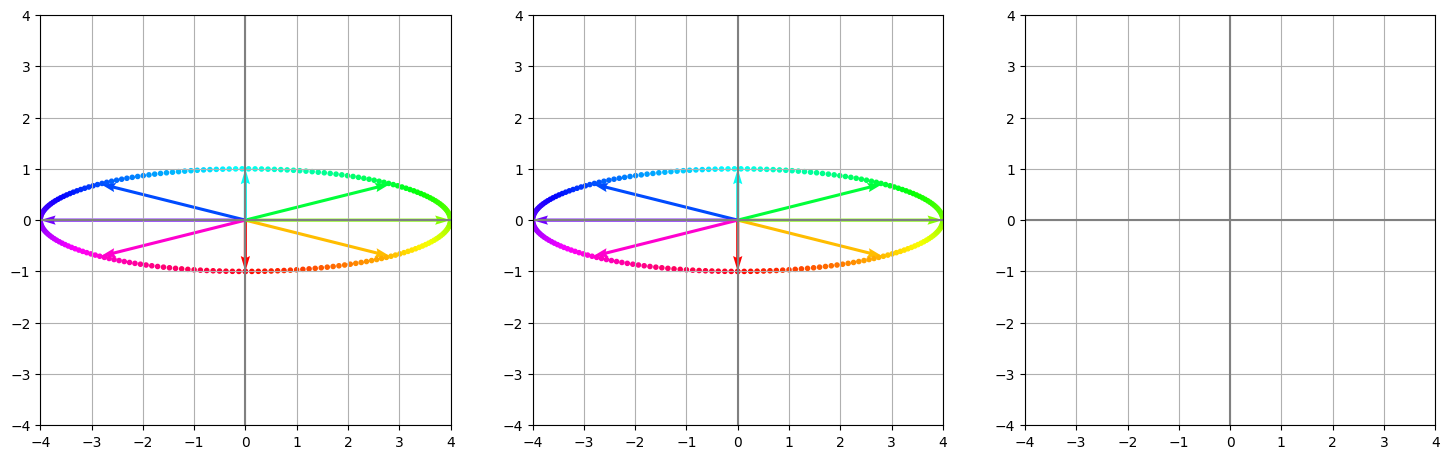

In [22]:
# you can start with this code cell.
D = np.diag([1,4])
R = RotationMatrix2D(3* np.pi/2)

DonArrows = D @ List_of_Arrows_on_Circle
DonCircle = D @ UnitCirclePoints

RonDonCircle = R @ DonCircle
RonDonArrows = R @ DonArrows

fig,ax = LADS2DSquare(ncols=3,xlow=-4.,xhigh=4.)

ax[0].LADS2DDrawVectorList(RonDonArrows,columns=True)
ax[0].scatter(*RonDonCircle,marker=".",c=colors,cmap=cm.hsv)
ax[1].LADS2DDrawVectorList(RonDonArrows,columns=True)
ax[1].scatter(*RonDonCircle,marker=".",c=colors,cmap=cm.hsv)


### Matrix multiplication doesn't necessarily commute

If $F$ and $G$ are two matrices, you may be able to make $FG$ even when $GF$ doesn't make sense. Here is a numerical example. 

In [23]:
# Here is a random 2-by-3 matrix F
F = rng.integers(low=-5.,high=5.,size=(2,3))
print("Here is F:")
print(F)

# And here is a random 3-by-3 matrix G
print("Here is G:")
G = rng.integers(low=-5.,high=5.,size=(3,3))
print(G)

Here is F:
[[4 3 0]
 [3 3 1]]
Here is G:
[[-1  4  0]
 [-3  2  2]
 [ 4  1  3]]


In [24]:
# Let's try to form the product $FG$.

print("Here is FG:")
print (F@G)

Here is FG:
[[-13  22   6]
 [ -8  19   9]]


In [25]:
# Now let's try to form the product $GF$.

print("Here is GF:")
print(G@F)

Here is GF:


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

#### **Do it:** Did $FG = GF$? 
Why not? Why did Python complain when you tried to calculate $GF$? 

**Edit this text cell** to put your answer here.
-- The program complained because it was trying to multiply a 3x3 by a 2x3 matrix. Using n x k @ k x m  is proper form, when k is constant and m > n

Even when $FG$ and $GF$ both make sense, they still are usually not equal. Let's see a 2D example, using our matrices $R$ and $D$ from above. They're both 2 by 2 matrices, so both products $RD$ and $DR$ exist. We'll apply $RD$ and $DR$ to the unit circle, and see that we get different results.

Text(0.5, 1.0, 'D@R applied to the unit circle')

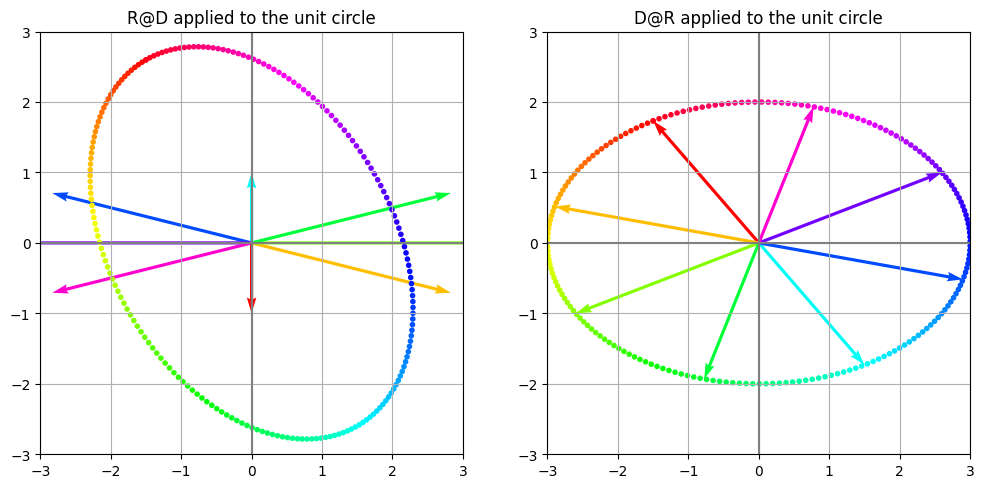

In [29]:
# Let's return to our 2D matrices D and R.

D = np.diag([3,2])
R = RotationMatrix2D(2* np.pi/3)

fig,ax = LADS2DSquare(ncols=2,xlow=-3.,xhigh=3.)

#Let's apply RD applied to the unit circle

RDonArrows = (R @ D) @ List_of_Arrows_on_Circle
RDonCircle = (R @ D) @ UnitCirclePoints

ax[0].LADS2DDrawVectorList(RonDonArrows,columns=True)
ax[0].scatter(*RDonCircle,marker=".",c=colors,cmap=cm.hsv)
ax[0].set_title("R@D applied to the unit circle")

#Now let's apply DR applied to the unit circle

DRonArrows = (D @ R) @ List_of_Arrows_on_Circle
DRonCircle = (D @ R) @ UnitCirclePoints

ax[1].LADS2DDrawVectorList(DRonArrows,columns=True)
ax[1].scatter(*DRonCircle,marker=".",c=colors,cmap=cm.hsv)
ax[1].set_title("D@R applied to the unit circle")



Those are different! Can you explain why? It may help to use the fact that $R@D$ means do $D$ first, then $R$, while $D@R$ means do $R$ first, then $D$. Let's draw those separately.

Text(0.5, 1.0, 'RD applied to the unit circle')

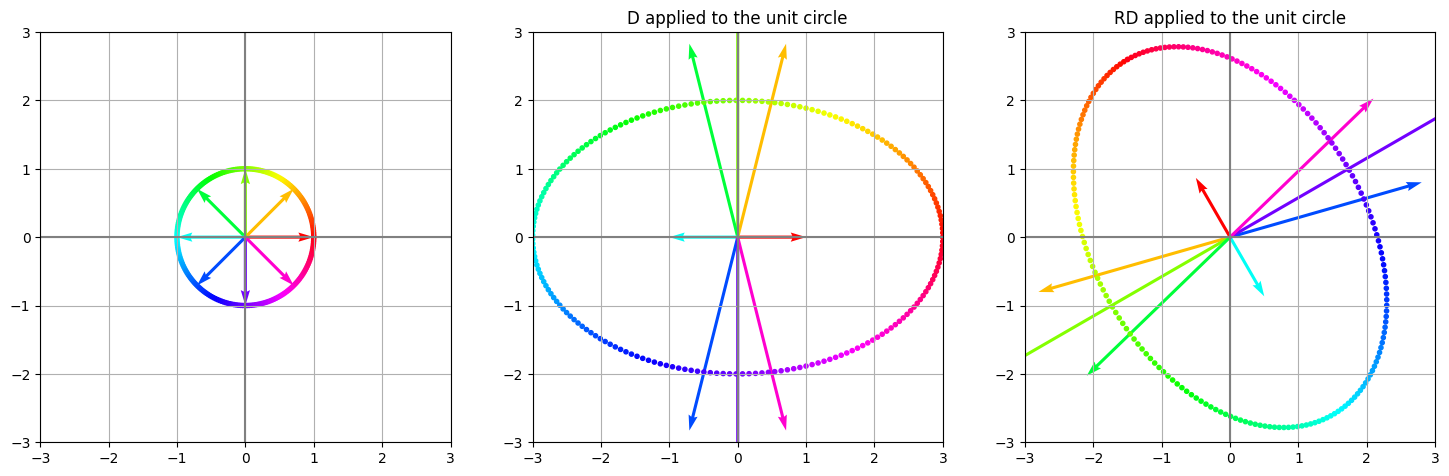

In [30]:
# Let's build up RD in order.

D = np.diag([3,2])
R = RotationMatrix2D(2* np.pi/3)

fig,ax = LADS2DSquare(ncols=3,xlow=-3.,xhigh=3.)

ax[0].LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)


#Let's apply D first

DArrows = D @ List_of_Arrows_on_Circle
DonCircle = D @ UnitCirclePoints


ax[1].LADS2DDrawVectorList(DonArrows,columns=True)
ax[1].scatter(*DonCircle,marker=".",c=colors,cmap=cm.hsv)
ax[1].set_title("D applied to the unit circle")

# Now apply R

ax[2].LADS2DDrawVectorList(R@DonArrows,columns=True)
ax[2].scatter(*(R@DonCircle),marker=".",c=colors,cmap=cm.hsv)
ax[2].set_title("RD applied to the unit circle")



Text(0.5, 1.0, 'DR applied to the unit circle')

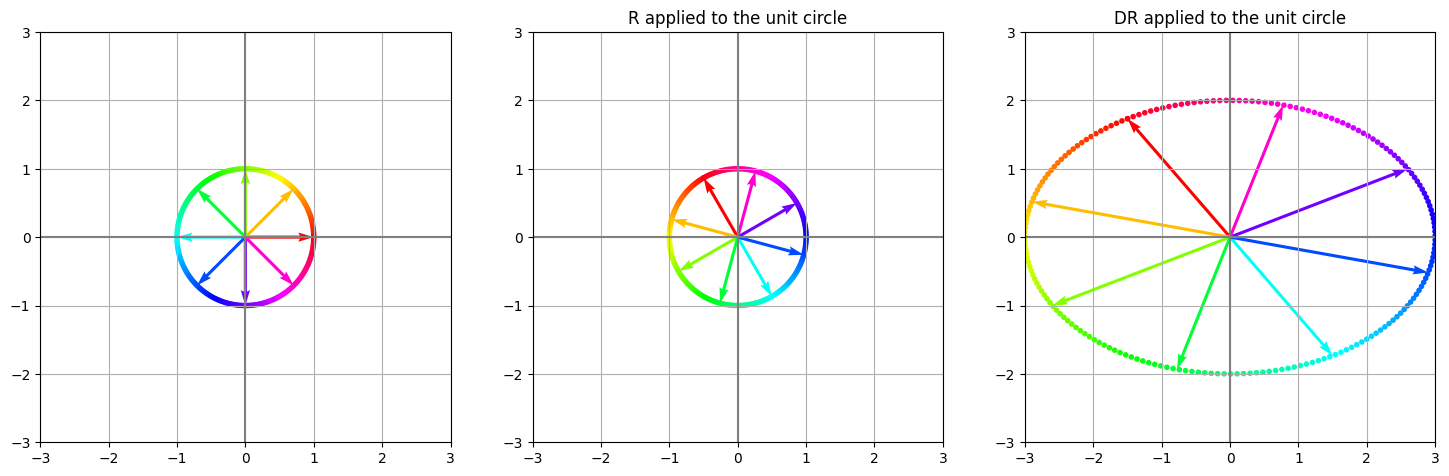

In [31]:
# Now let's build up DR in order

D = np.diag([3,2])
R = RotationMatrix2D(2* np.pi/3)

fig,ax = LADS2DSquare(ncols=3,xlow=-3.,xhigh=3.)

ax[0].LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

#Let's apply R first

RonArrows = R @ List_of_Arrows_on_Circle
RonCircle = R @ UnitCirclePoints


ax[1].LADS2DDrawVectorList(RonArrows,columns=True)
ax[1].scatter(*RonCircle,marker=".",c=colors,cmap=cm.hsv)
ax[1].set_title("R applied to the unit circle")

# Now apply D

ax[2].LADS2DDrawVectorList(D@RonArrows,columns=True)
ax[2].scatter(*(D@RonCircle),marker=".",c=colors,cmap=cm.hsv)
ax[2].set_title("DR applied to the unit circle")



#### **Do it:** Explain why $RD$ applied to the unit circle does not look like $DR$ applied to the unit circle.

In particular, explain why the ellipse you get from $RD$ has its long axis along the 120 degree line, while the ellipse you get from $DR$ has its long axis along the $x$-axis.

**Edit this text cell** and put your answer here. 

The RD circle is expanded by D and then roated by R, while DR is first rotated then expanded. When you expand it also expands the rotation so DR is expanded even further

By the way, $RD$ and $DR$ have different entries.

In [32]:
print("Here is RD:")
print(R@D)

print("Here is DR:")
print(D@R)

Here is RD:
[[-1.5        -1.73205081]
 [ 2.59807621 -1.        ]]
Here is DR:
[[-1.5        -2.59807621]
 [ 1.73205081 -1.        ]]


So you can see just from the entries that $RD$ and $DR$ are different matrices. But isn't it illuminating to explore this in terms of what the matrices do to $2D$ vectors

## Membership matrices and another example of matrix multiplication

The goals of this example are:

1. Practice reading data from a CSV file
2. See an example of a "Membership matrix", another kind of data that is very common in data science
3. See what matrix multiplication means for a membership matrix, and in particular...
4. ...starting with a membership matrix $M$, interpret the two products $M^T M$ and $M M^T$.


### Reading spreadsheet data with pandas

First read the file "club list CSV.csv" into a panda dataframe called df. If you are able, have a look at the CSV file.

In [33]:
df = pd.read_csv('club list CSV.csv',index_col=0)

Let's see what df looks like.

In [34]:
df

,Basketball,Football,Soccer,Swimming,Track,X Country,Band,Choir,Orchestra,Chinese,French,German,Spanish
Amy,0,0,1,1,0,1,1,0,1,1,1,0,0
Brad,1,1,0,0,1,0,1,1,0,1,0,1,0
Cynthia,0,0,1,0,0,1,0,0,1,0,0,0,1
David,0,0,1,1,0,0,0,1,1,0,1,1,1
Ellen,1,0,1,0,0,1,1,0,0,1,1,0,0
Frank,1,0,0,0,1,1,0,1,0,0,0,1,0
Georgia,0,1,1,0,0,1,0,0,0,0,0,1,1
Harry,0,0,0,0,0,1,0,1,0,1,0,0,1
Ingrid,0,1,0,1,1,0,1,1,0,1,1,0,1
Jack,1,1,0,1,0,0,1,1,1,0,1,0,1


Notice that pandas used the zero row of the spreadsheet to name the columns of the data frame, also called "keys". It also used the zero column to name the rows, called the "index". Actually, in the pd.read_csv function above, the optional argument "index_col=0" told pandas to use the zero column as the index.

In [35]:
# Let's see how to get data we want. 
# You can get the information about one row by selecting its name
df.loc["Ingrid"]

Basketball    0
Football      1
Soccer        0
Swimming      1
Track         1
X Country     0
Band          1
Choir         1
Orchestra     0
Chinese       1
French        1
German        0
Spanish       1
Name: Ingrid, dtype: int64

In [36]:
# You can get infromation about a column by slicing 
df.loc[:,"Basketball"]

Amy        0
Brad       1
Cynthia    0
David      0
Ellen      1
Frank      1
Georgia    0
Harry      0
Ingrid     0
Jack       1
Karen      1
Name: Basketball, dtype: int64

You can get the names of the columns using "columns" or "keys()":

In [37]:
df.columns

Index(['Basketball', 'Football', 'Soccer', 'Swimming', 'Track', 'X Country',
       'Band', 'Choir', 'Orchestra', 'Chinese', 'French', 'German', 'Spanish'],
      dtype='object')

In [38]:
df.keys()

Index(['Basketball', 'Football', 'Soccer', 'Swimming', 'Track', 'X Country',
       'Band', 'Choir', 'Orchestra', 'Chinese', 'French', 'German', 'Spanish'],
      dtype='object')

You can get the names of the rows using "index":

In [39]:
df.index

Index(['Amy', 'Brad', 'Cynthia', 'David', 'Ellen', 'Frank', 'Georgia', 'Harry',
       'Ingrid', 'Jack', 'Karen'],
      dtype='object')

We'll want both of these as Python "lists", which are like numpy arrays.

In [40]:
activities = list(df.keys())
print(activities)
students = list(df.index)
print(students)

['Basketball', 'Football', 'Soccer', 'Swimming', 'Track', 'X Country', 'Band', 'Choir', 'Orchestra', 'Chinese', 'French', 'German', 'Spanish']
['Amy', 'Brad', 'Cynthia', 'David', 'Ellen', 'Frank', 'Georgia', 'Harry', 'Ingrid', 'Jack', 'Karen']


Let's check how many activities and students we have.

In [41]:
print(f"The number of activities is {len(activities)}.")
print(f"The number of students is {len(students)}.")

The number of activities is 13.
The number of students is 11.


Now we'll turn the zeroes and ones in the dataframe into a matrix: pandas makes this as easy as possible. If `df` is a data frame, then the method `df.to_numpy()` turns the data frame into a matrix. We'll also print the matrix to make sure we're getting the right information.

In [42]:
M = df.to_numpy()
print(M)

[[0 0 1 1 0 1 1 0 1 1 1 0 0]
 [1 1 0 0 1 0 1 1 0 1 0 1 0]
 [0 0 1 0 0 1 0 0 1 0 0 0 1]
 [0 0 1 1 0 0 0 1 1 0 1 1 1]
 [1 0 1 0 0 1 1 0 0 1 1 0 0]
 [1 0 0 0 1 1 0 1 0 0 0 1 0]
 [0 1 1 0 0 1 0 0 0 0 0 1 1]
 [0 0 0 0 0 1 0 1 0 1 0 0 1]
 [0 1 0 1 1 0 1 1 0 1 1 0 1]
 [1 1 0 1 0 0 1 1 1 0 1 0 1]
 [1 0 0 1 0 0 0 0 1 0 0 0 1]]


In [43]:
df

,Basketball,Football,Soccer,Swimming,Track,X Country,Band,Choir,Orchestra,Chinese,French,German,Spanish
Amy,0,0,1,1,0,1,1,0,1,1,1,0,0
Brad,1,1,0,0,1,0,1,1,0,1,0,1,0
Cynthia,0,0,1,0,0,1,0,0,1,0,0,0,1
David,0,0,1,1,0,0,0,1,1,0,1,1,1
Ellen,1,0,1,0,0,1,1,0,0,1,1,0,0
Frank,1,0,0,0,1,1,0,1,0,0,0,1,0
Georgia,0,1,1,0,0,1,0,0,0,0,0,1,1
Harry,0,0,0,0,0,1,0,1,0,1,0,0,1
Ingrid,0,1,0,1,1,0,1,1,0,1,1,0,1
Jack,1,1,0,1,0,0,1,1,1,0,1,0,1


The matrix $M$ is an example of a "membership matrix": it has a list of activities or organizations as columns, and a list of persons as rows. The $(i,j)$ entry is $1$ if person $i$ participates in activity $j$, and $0$ if not. 

You can transpose a data frame.

In [44]:
df.transpose()

,Amy,Brad,Cynthia,David,Ellen,Frank,Georgia,Harry,Ingrid,Jack,Karen
Basketball,0,1,0,0,1,1,0,0,0,1,1
Football,0,1,0,0,0,0,1,0,1,1,0
Soccer,1,0,1,1,1,0,1,0,0,0,0
Swimming,1,0,0,1,0,0,0,0,1,1,1
Track,0,1,0,0,0,1,0,0,1,0,0
X Country,1,0,1,0,1,1,1,1,0,0,0
Band,1,1,0,0,1,0,0,0,1,1,0
Choir,0,1,0,1,0,1,0,1,1,1,0
Orchestra,1,0,1,1,0,0,0,0,0,1,1
Chinese,1,1,0,0,1,0,0,1,1,0,0


You can also transpose just the membership matrix. Compare the output of the next cell to the tranposed dataframe to be sure the information matches.

In [45]:
M.T

array([[0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1],
       [0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0],
       [1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1],
       [0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0],
       [1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
       [1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1],
       [1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0],
       [0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1]])

In [46]:
print(M.shape)
print(len(students))
print(len(activities))

(11, 13)
11
13


As you can see above, $M$ has one row for each student and one row for each activity. Now let's look at the shape of $M^T$, the transpose of $M$.

In [47]:
print(M.T.shape)

(13, 11)


Notice that the number of columns of $M$ matches the number of rows of $M.T$: they're both $13$. This means we can multiply $M$ by $M.T$.

In [48]:
MMT = M@ M.T

In [49]:
print(MMT)
print(MMT.shape)

[[7 2 3 4 5 1 2 2 4 4 2]
 [2 7 0 2 3 4 2 2 5 4 1]
 [3 0 4 3 2 1 3 2 1 2 2]
 [4 2 3 7 2 2 3 2 4 5 3]
 [5 3 2 2 6 2 2 2 3 3 1]
 [1 4 1 2 2 5 2 2 2 2 1]
 [2 2 3 3 2 2 5 2 2 2 1]
 [2 2 2 2 2 2 2 4 3 2 1]
 [4 5 1 4 3 2 2 3 8 6 2]
 [4 4 2 5 3 2 2 2 6 8 4]
 [2 1 2 3 1 1 1 1 2 4 4]]
(11, 11)


That's a little hard to intepret so let's convert it back to a data frame. We got an 11 by 11 matrix because 11 is the number of students, so we'll use the student names to label the rows and the columns.

In [50]:
MMTFrame = pd.DataFrame(MMT,columns=students,index=students)

In [51]:
MMTFrame

,Amy,Brad,Cynthia,David,Ellen,Frank,Georgia,Harry,Ingrid,Jack,Karen
Amy,7,2,3,4,5,1,2,2,4,4,2
Brad,2,7,0,2,3,4,2,2,5,4,1
Cynthia,3,0,4,3,2,1,3,2,1,2,2
David,4,2,3,7,2,2,3,2,4,5,3
Ellen,5,3,2,2,6,2,2,2,3,3,1
Frank,1,4,1,2,2,5,2,2,2,2,1
Georgia,2,2,3,3,2,2,5,2,2,2,1
Harry,2,2,2,2,2,2,2,4,3,2,1
Ingrid,4,5,1,4,3,2,2,3,8,6,2
Jack,4,4,2,5,3,2,2,2,6,8,4


#### **Do it:** Answer these questions.

1. What is the meaning of the number in row and column, when the row and column labels or numbers aren't equal? 
    It's the amount of activities the students have together
2. What is the meaning of the diagonal entries?
    It's the total amount of activities that students can participate in
3. This matrix is "symmetric": the entry for row "Cynthia" and "David" is the same as the entry for row "David" and column "Cynthia", and so forth. Why? 
    A matrix multiplied by the transpose is always symmetric

**Edit this text cell** to put your answers here.

Hints: you may find it useful to look at some specific cases.

In [52]:
# Here are the entries for Amy and Brad.
df.loc["Amy":"Brad"]

,Basketball,Football,Soccer,Swimming,Track,X Country,Band,Choir,Orchestra,Chinese,French,German,Spanish
Amy,0,0,1,1,0,1,1,0,1,1,1,0,0
Brad,1,1,0,0,1,0,1,1,0,1,0,1,0


In [54]:
amy = df.loc["Amy"].to_numpy()
print(amy)

[0 0 1 1 0 1 1 0 1 1 1 0 0]


In [55]:
brad = df.loc["Brad"].to_numpy()
print(brad)

[1 1 0 0 1 0 1 1 0 1 0 1 0]


In [56]:
print(amy@amy)
print(amy@brad)
print(brad@amy)
print(brad@brad)

7
2
2
7


What are the dot products above telling you? Does that help you answer the "Do it" questions about the matrix $M@ M.T$?

Let's go back and look at the shape of $M$ and $M.T$ again.

In [57]:
print(M.shape)
print(M.T.shape)

(11, 13)
(13, 11)


Notice that the number of columns of $M.T$ is $11$, and the number of rows of $M$ is $11$. So we can multiply $M.T$ by $M$! 

In [58]:
MTM = M.T @ M
print(MTM)
print(MTM.shape)

[[5 2 1 2 2 2 3 3 2 2 2 2 2]
 [2 4 1 2 2 1 3 3 1 2 2 2 3]
 [1 1 5 2 0 4 2 1 3 2 3 2 3]
 [2 2 2 5 1 1 3 3 4 2 4 1 4]
 [2 2 0 1 3 1 2 3 0 2 1 2 1]
 [2 1 4 1 1 6 2 2 2 3 2 2 3]
 [3 3 2 3 2 2 5 3 2 4 4 1 2]
 [3 3 1 3 3 2 3 6 2 3 3 3 4]
 [2 1 3 4 0 2 2 2 5 1 3 1 4]
 [2 2 2 2 2 3 4 3 1 5 3 1 2]
 [2 2 3 4 1 2 4 3 3 3 5 1 3]
 [2 2 2 1 2 2 1 3 1 1 1 4 2]
 [2 3 3 4 1 3 2 4 4 2 3 2 7]]
(13, 13)


This time we got a 13 by 13 matrix. To understand it better, let's convert it back into a dataframe, labeled with the 13 activites. 

In [59]:
MTMFrame = pd.DataFrame(MTM,columns=activities,index=activities)
MTMFrame

,Basketball,Football,Soccer,Swimming,Track,X Country,Band,Choir,Orchestra,Chinese,French,German,Spanish
Basketball,5,2,1,2,2,2,3,3,2,2,2,2,2
Football,2,4,1,2,2,1,3,3,1,2,2,2,3
Soccer,1,1,5,2,0,4,2,1,3,2,3,2,3
Swimming,2,2,2,5,1,1,3,3,4,2,4,1,4
Track,2,2,0,1,3,1,2,3,0,2,1,2,1
X Country,2,1,4,1,1,6,2,2,2,3,2,2,3
Band,3,3,2,3,2,2,5,3,2,4,4,1,2
Choir,3,3,1,3,3,2,3,6,2,3,3,3,4
Orchestra,2,1,3,4,0,2,2,2,5,1,3,1,4
Chinese,2,2,2,2,2,3,4,3,1,5,3,1,2


#### **Do it:**
1. Display two of the rows of this dataframe (e.g. "Band" and "Chinese").
2. Extract each of those two rows into numpy arrays
2. Compute the dot product of each row with itself and with the other row

In [60]:
# You can do your work in code cells starting here.

Orchestra = MTMFrame.loc["Orchestra"].to_numpy()
Chinese = MTMFrame.loc["Chinese"].to_numpy()

print(Orchestra)
print(Chinese)

print("\nOrchestra@Chinese = ", Orchestra@Chinese)
print("Chinese@Orchestra = ", Chinese@Orchestra)

MTMFrame.loc["Orchestra":"Chinese"]

[2 1 3 4 0 2 2 2 5 1 3 1 4]
[2 2 2 2 2 3 4 3 1 5 3 1 2]

Orchestra@Chinese =  68
Chinese@Orchestra =  68


,Basketball,Football,Soccer,Swimming,Track,X Country,Band,Choir,Orchestra,Chinese,French,German,Spanish
Orchestra,2,1,3,4,0,2,2,2,5,1,3,1,4
Chinese,2,2,2,2,2,3,4,3,1,5,3,1,2


#### **Do it:** Answer these questions.

1. What is the meaning of the number in row and column, when the row and column labels or numbers aren't equal? 
    The amount of students in both activites
2. What is the meaning of the diagonal entries?
    The amount of students in a particular activity
3. The matrix is symmetric again. Why does that make sense. 
    Matricies that are multiplied by their transpose are always symmetric

**Edit this text cell to put in your answers**

## Conclusion

This example is a very important example of modeling data using vectors and matrices. You've repesented membership and networks using matrices. We'll see later in the course that linear algebra provides powerful tools for analyzing networks.

Along the way, you saw that the product of matrices has an interesting interpretation in this context. You saw for the first time that you can form the product $M @ M.T$ and $M.T @ M.$ By the way, $M@M.T$ and $M.T @M$ are not equal, and have different but related interpretations. This is another example showing that, for matrix products, order matters: multiplication is not commutative.